<a href="https://colab.research.google.com/github/sajjkavinda/ML-based-Intrution-detection-system/blob/main/DecisionTree_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree Model Training and Evaluation

The objective of this stage is to evaluate the capability of a lightweight supervised learning algorithm in detecting malicious network traffic while considering computational efficiency and model performance.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import libraries

In [5]:
import pandas as pd
import numpy as np
import time
import pickle
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

Set paths to the Dataset and Output

In [3]:
PROJECT_DIR = Path("/content/drive/MyDrive/MSc_Dissertation")

PROCESSED_DIR = PROJECT_DIR / "Dataset/Processed"

RESULTS_DIR = PROJECT_DIR / "Results"

MODEL_DIR = RESULTS_DIR / "Models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

Load Training and Test Datasets

In [6]:
with open(PROCESSED_DIR / "X_train.pkl", "rb") as f:
    X_train = pickle.load(f)

with open(PROCESSED_DIR / "X_test.pkl", "rb") as f:
    X_test = pickle.load(f)

with open(PROCESSED_DIR / "y_train.pkl", "rb") as f:
    y_train = pickle.load(f)

with open(PROCESSED_DIR / "y_test.pkl", "rb") as f:
    y_test = pickle.load(f)


print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (340408, 30)
Testing data: (85103, 30)


Create the Decision Tree Model

In [7]:
dt_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=20,
    random_state=42
)

Train the model

In [18]:
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=8,
    min_samples_split=100,
    min_samples_leaf=50
)

start_time = time.time()


dt.fit(
    X_train,
    y_train
)

training_time = time.time() - start_time


print(
    f"Training time: {training_time:.2f} seconds"
)

Training time: 2.95 seconds


Make predictions

In [19]:
start_prediction = time.time()

y_pred = dt.predict(
    X_test
)

prediction_time = time.time() - start_prediction


print(
    f"Prediction time: {prediction_time:.4f} seconds"
)

Prediction time: 0.0069 seconds


Evaluate performance

In [20]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

Accuracy: 0.9999


In [11]:
Classification report

SyntaxError: invalid syntax (40644869.py, line 1)

In [12]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     78046
           1       1.00      1.00      1.00      7057

    accuracy                           1.00     85103
   macro avg       1.00      1.00      1.00     85103
weighted avg       1.00      1.00      1.00     85103



Confusion matrix

[[78044     2]
 [    3  7054]]


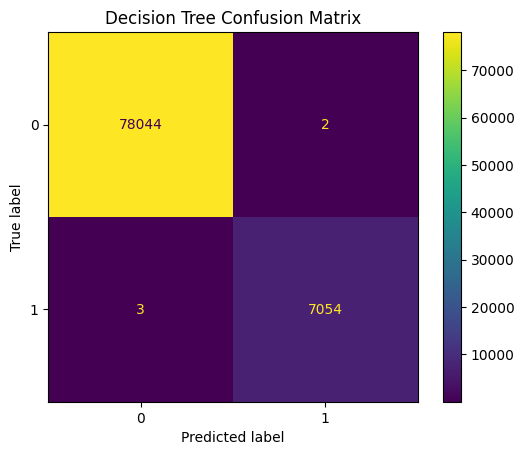

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred
)


print(cm)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.show()

Feature importance

In [14]:
feature_importance = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": dt.feature_importances_
    }
)


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


feature_importance.head(20)

,Feature,Importance
20,Flow Duration,0.613938
0,Fwd Seg Size Min,0.318435
26,Bwd Pkt Len Max,0.033634
5,Fwd IAT Min,0.012625
2,Init Fwd Win Byts,0.010096
18,Pkt Len Max,0.005590
28,Bwd Pkt Len Mean,0.005230
6,Fwd Pkts/s,0.000426
8,Fwd IAT Max,0.000015
22,Pkt Size Avg,0.000004


Plot feature importance

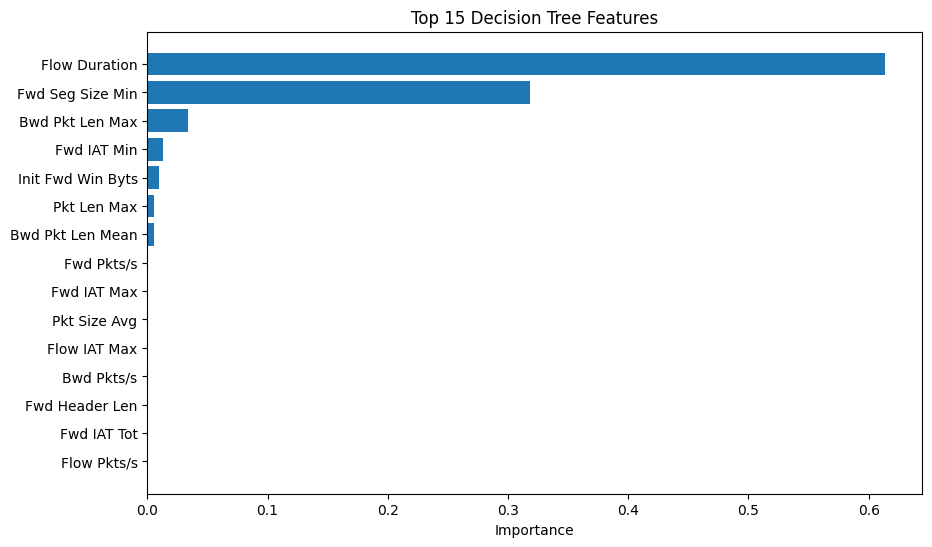

In [15]:
top_features = feature_importance.head(15)


plt.figure(figsize=(10,6))


plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)


plt.gca().invert_yaxis()


plt.xlabel(
    "Importance"
)

plt.title(
    "Top 15 Decision Tree Features"
)


plt.show()

Save the model

In [16]:
MODEL_PATH = PROCESSED_DIR / "decision_tree_model.pkl"


joblib.dump(
    dt,
    MODEL_PATH
)


print(
    "Model saved:"
)

print(
    MODEL_PATH
)

Model saved:
/content/drive/MyDrive/MSc_Dissertation/Dataset/Processed/decision_tree_model.pkl


Save the results

In [17]:
results = pd.DataFrame(
    {
        "Model": ["Decision Tree"],
        "Accuracy": [accuracy],
        "Training Time (seconds)": [training_time],
        "Prediction Time (seconds)": [prediction_time]
    }
)


RESULT_PATH = PROCESSED_DIR / "decision_tree_results.csv"


results.to_csv(
    RESULT_PATH,
    index=False
)


results

,Model,Accuracy,Training Time (seconds),Prediction Time (seconds)
0,Decision Tree,0.999941,2.876623,0.005879
